In [21]:
import numpy as np
from scipy.signal import find_peaks
from typing import List, Tuple, Dict

def detect_all_acceleration_minima_frames(
    clip_data: List[Dict], 
    prominence_threshold: float = 0.1,
    distance_threshold: int = 3,
    frames_after_minimum: int = 5
) -> Dict[int, List[List[int]]]:
    """
    Detect ALL local and extreme minima (≤ 0) in tangential acceleration per clip
    and return the next 4 frames for each minimum for zero-shot TIL frame filtering.
    
    Parameters:
    -----------
    clip_data : List[Dict]
        Output from process_landmarks_by_clips() containing frames and accelerations
    prominence_threshold : float
        Minimum prominence for detecting significant minima (default: 0.1)
    distance_threshold : int  
        Minimum distance between detected minima in frames (default: 3)
    frames_after_minimum : int
        Number of additional frames after minimum to include (default: 4)
        
    Returns:
    --------
    Dict[int, List[List[int]]]
        Dictionary mapping clip_index to list of frame sequences
        Each sequence contains [min_frame, min_frame+1, min_frame+2, min_frame+3, min_frame+4]
        Multiple sequences per clip if multiple valid minima found
    """
    
    filtered_frame_sequences = {}
    
    for clip in clip_data:
        clip_idx = clip['clip_index']
        accelerations = np.array(clip['accelerations'])
        frames = np.array(clip['frames'])
        
        if len(accelerations) < 3:
            print(f"⚠️  Clip {clip_idx + 1}: Too few points for minima detection")
            filtered_frame_sequences[clip_idx] = []
            continue
        
        valid_minima = []  # Store all valid minima with their indices
        
        # 1. Check for EXTREME MINIMUM at the START
        if accelerations[0] <= 0:
            # Check if it's increasing from the start (making start point a local minimum)
            if len(accelerations) > 1 and accelerations[1] > accelerations[0]:
                valid_minima.append((0, frames[0], accelerations[0], "start_extreme"))
                print(f"Clip {clip_idx + 1}: Start extreme minimum at frame {frames[0]} ({accelerations[0]:.3f})")
        
        # 2. Check for EXTREME MINIMUM at the END
        if accelerations[-1] <= 0:
            # Check if it's decreasing to the end (making end point a local minimum)
            if len(accelerations) > 1 and accelerations[-2] > accelerations[-1]:
                valid_minima.append((len(accelerations)-1, frames[-1], accelerations[-1], "end_extreme"))
                print(f"Clip {clip_idx + 1}: End extreme minimum at frame {frames[-1]} ({accelerations[-1]:.3f})")
        
        # 3. Find INTERIOR LOCAL MINIMA using scipy
        inverted_acceleration = -accelerations
        minima_indices, properties = find_peaks(
            inverted_acceleration,
            prominence=prominence_threshold,
            distance=distance_threshold
        )
        
        # Add interior minima with value ≤ 0
        for min_idx in minima_indices:
            if accelerations[min_idx] <= 0:
                # Avoid duplicates with extreme minima
                if min_idx != 0 and min_idx != len(accelerations)-1:
                    valid_minima.append((min_idx, frames[min_idx], accelerations[min_idx], "interior_local"))
                    print(f"Clip {clip_idx + 1}: Interior local minimum at frame {frames[min_idx]} ({accelerations[min_idx]:.3f})")
        
        # 4. Generate frame sequences for all valid minima
        frame_sequences = []
        
        # Sort minima by frame number to process in chronological order
        valid_minima.sort(key=lambda x: x[1])  # Sort by frame number
        
        for min_idx, min_frame, min_value, min_type in valid_minima:
            frame_sequence = []
            
            # Create sequence of 5 consecutive frames starting from minimum
            for i in range(frames_after_minimum + 1):  # +1 to include the minimum frame
                target_frame = min_frame + i
                
                # Check if target frame exists in current clip's frame range
                if target_frame <= frames[-1]:  # Within clip boundary
                    frame_sequence.append(int(target_frame))
                else:
                    break  # Stop if we exceed clip boundary
            
            # Only add sequences that have the minimum frame + at least 1 additional frame
            if len(frame_sequence) >= 2:
                frame_sequences.append(frame_sequence)
                print(f"  → {min_type.replace('_', ' ').title()}: Frames {frame_sequence}")
            else:
                print(f"  → {min_type.replace('_', ' ').title()}: Insufficient frames after minimum")
        
        filtered_frame_sequences[clip_idx] = frame_sequences
        print(f"Clip {clip_idx + 1}: Found {len(valid_minima)} valid minima (≤ 0), "
              f"generated {len(frame_sequences)} frame sequences")
    
    return filtered_frame_sequences

def extract_all_minima_frames(filtered_sequences: Dict[int, List[List[int]]]) -> List[int]:
    """
    Extract all filtered frame numbers from all minima sequences.
    
    Parameters:
    -----------
    filtered_sequences : Dict[int, List[List[int]]]
        Output from detect_all_acceleration_minima_frames()
        
    Returns:
    --------
    List[int]
        Flattened list of all filtered frame numbers across all clips and sequences
    """
    all_frames = []
    
    for clip_idx, sequences in filtered_sequences.items():
        for sequence in sequences:
            all_frames.extend(sequence)
    
    # Remove duplicates and sort
    return sorted(list(set(all_frames)))

def visualize_all_minima_frames(clip_data: List[Dict], 
                               filtered_sequences: Dict[int, List[List[int]]],
                               cs_annotations: List[Tuple[int, int]]) -> None:
    """
    Visualize the acceleration plot with ALL detected minima and their frame sequences.
    """
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    
    # Plot acceleration curves for each clip
    for clip in clip_data:
        ax.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8, label='Acceleration' if clip['clip_index'] == 0 else "")
    
    # Mark detected minima and frame sequences with different colors
    colors = ['red', 'orange', 'purple', 'brown', 'pink', 'cyan', 'magenta', 'yellow']
    marker_shapes = ['v', '^', 's', 'D', 'o', 'h', 'p', '*']
    
    minima_legend_added = False
    sequence_legend_added = False
    
    for clip_idx, sequences in filtered_sequences.items():
        if not sequences:  # Skip empty sequences
            continue
            
        clip = next(c for c in clip_data if c['clip_index'] == clip_idx)
        
        for seq_idx, frame_sequence in enumerate(sequences):
            color = colors[seq_idx % len(colors)]
            marker = marker_shapes[seq_idx % len(marker_shapes)]
            
            # Highlight the minimum frame (first in sequence)
            min_frame = frame_sequence[0]
            min_acc_idx = np.where(np.array(clip['frames']) == min_frame)[0]
            if len(min_acc_idx) > 0:
                min_acc_value = clip['accelerations'][min_acc_idx[0]]
                ax.scatter([min_frame], [min_acc_value], 
                          c=color, s=150, marker=marker, 
                          label=f'All Minima (≤ 0)' if not minima_legend_added else "",
                          edgecolors='black', linewidth=2, alpha=0.9)
                minima_legend_added = True
                
                # Mark the following frames in sequence
                for frame in frame_sequence[1:]:  # Skip the minimum frame itself
                    frame_idx = np.where(np.array(clip['frames']) == frame)[0]
                    if len(frame_idx) > 0:
                        acc_value = clip['accelerations'][frame_idx[0]]
                        ax.scatter([frame], [acc_value], 
                                  c=color, s=60, alpha=0.7, marker='o',
                                  label=f'Selected Sequences' if not sequence_legend_added else "",
                                  edgecolors='black', linewidth=1)
                        sequence_legend_added = True
    
    # Add contact/separation events for context
    for i, (contact, separation) in enumerate(cs_annotations):
        ax.axvline(x=contact, color='green', linestyle='-', alpha=0.6, 
                  label='Contact Events' if i == 0 else "")
        ax.axvline(x=separation, color='red', linestyle='-', alpha=0.6,
                  label='Separation Events' if i == 0 else "")
    
    # Add horizontal line at y=0 for reference
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Zero Line')
    
    ax.set_xlabel('Frame Number')
    ax.set_ylabel('Tangential Acceleration')
    ax.set_title('All Local & Extreme Minima Detection (≤ 0) for Zero-Shot TIL Frame Filtering')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


In [22]:
from scipy.signal import find_peaks

def detect_first_acceleration_minimum_frames(
    clip_data: List[dict], 
    prominence_threshold: float = 0.1,
    distance_threshold: int = 3,
    frames_after_minimum: int = 5
) -> dict:
    """
    Detect the FIRST local minimum (≤ 0) in tangential acceleration per clip
    and return the next 4 frames for zero-shot TIL frame filtering.
    """
    filtered_frame_sequences = {}
    
    for clip in clip_data:
        clip_idx = clip['clip_index']
        accelerations = np.array(clip['accelerations'])
        frames = np.array(clip['frames'])
        
        if len(accelerations) < 3:
            print(f"⚠️  Clip {clip_idx + 1}: Too few points for minima detection")
            filtered_frame_sequences[clip_idx] = []
            continue
        
        first_minimum_frame = None
        first_minimum_value = None
        
        # Check if clip starts with negative value and is a local minimum
        if accelerations[0] <= 0:
            if len(accelerations) > 1 and accelerations[1] > accelerations[0]:
                first_minimum_frame = frames[0]
                first_minimum_value = accelerations[0]
                print(f"Clip {clip_idx + 1}: Edge case - Start frame {first_minimum_frame} is local minimum ({first_minimum_value:.3f})")
        
        # If no edge case minimum found, search for interior local minima
        if first_minimum_frame is None:
            inverted_acceleration = -accelerations
            minima_indices, properties = find_peaks(
                inverted_acceleration,
                prominence=prominence_threshold,
                distance=distance_threshold
            )
            
            # Find the first minimum with value <= 0
            for min_idx in minima_indices:
                if accelerations[min_idx] <= 0:
                    first_minimum_frame = frames[min_idx]
                    first_minimum_value = accelerations[min_idx]
                    print(f"Clip {clip_idx + 1}: First local minimum at frame {first_minimum_frame} ({first_minimum_value:.3f})")
                    break
        
        # Generate frame sequence if valid minimum found
        if first_minimum_frame is not None:
            frame_sequence = []
            for i in range(frames_after_minimum + 1):
                target_frame = first_minimum_frame + i
                if target_frame <= frames[-1]:
                    frame_sequence.append(int(target_frame))
                else:
                    break
            
            if len(frame_sequence) >= 1:
                filtered_frame_sequences[clip_idx] = frame_sequence
                print(f"  → Selected frames: {frame_sequence}")
            else:
                filtered_frame_sequences[clip_idx] = []
        else:
            filtered_frame_sequences[clip_idx] = []
            print(f"Clip {clip_idx + 1}: No local minimum ≤ 0 found")
    
    return filtered_frame_sequences

def extract_all_first_minimum_frames(filtered_sequences: dict) -> List[int]:
    """Extract all filtered frame numbers from the first minimum sequences."""
    all_frames = []
    for clip_idx, sequence in filtered_sequences.items():
        if sequence:
            all_frames.extend(sequence)
    return sorted(list(set(all_frames)))

def visualize_first_minimum_frames(clip_data: List[dict], 
                                 filtered_sequences: dict,
                                 cs_annotations: List[tuple]) -> None:
    """Visualize the acceleration plot with detected first minima and their frame sequences."""
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    # Plot acceleration curves for each clip
    for clip in clip_data:
        ax.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8, label='Acceleration' if clip['clip_index'] == 0 else "")
    
    # Mark detected first minima and their frame sequences
    colors = ['red', 'orange', 'purple', 'brown', 'pink']
    minima_legend_added = False
    sequence_legend_added = False
    
    for clip_idx, frame_sequence in filtered_sequences.items():
        if not frame_sequence:
            continue
            
        clip = next(c for c in clip_data if c['clip_index'] == clip_idx)
        color = colors[clip_idx % len(colors)]
        
        # Highlight the minimum frame (first in sequence)
        min_frame = frame_sequence[0]
        min_acc_idx = np.where(np.array(clip['frames']) == min_frame)[0]
        if len(min_acc_idx) > 0:
            min_acc_value = clip['accelerations'][min_acc_idx[0]]
            ax.scatter([min_frame], [min_acc_value], 
                      c=color, s=150, marker='v', 
                      label=f'First Minima (≤ 0)' if not minima_legend_added else "",
                      edgecolors='black', linewidth=2)
            minima_legend_added = True
            
            # Mark the following frames in sequence
            for frame in frame_sequence[1:]:
                frame_idx = np.where(np.array(clip['frames']) == frame)[0]
                if len(frame_idx) > 0:
                    acc_value = clip['accelerations'][frame_idx[0]]
                    ax.scatter([frame], [acc_value], 
                              c=color, s=60, alpha=0.8, marker='o',
                              label=f'Filtered Frames (+4)' if not sequence_legend_added else "",
                              edgecolors='black', linewidth=1)
                    sequence_legend_added = True
    
    # Add contact/separation events for context
    for i, (contact, separation) in enumerate(cs_annotations):
        ax.axvline(x=contact, color='green', linestyle='-', alpha=0.6, 
                  label='Contact Events' if i == 0 else "")
        ax.axvline(x=separation, color='red', linestyle='-', alpha=0.6,
                  label='Separation Events' if i == 0 else "")
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Zero Line')
    ax.set_xlabel('Frame Number')
    ax.set_ylabel('Tangential Acceleration')
    ax.set_title('First Local Minimum Detection (≤ 0) for Zero-Shot TIL Frame Filtering')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


## Plotting

Loading landmark data...
Loaded 880 landmark frames
Loading clip ranges...
Loaded 30 clip segments
Loading contact/separation annotations...
Loaded 30 contact/separation pairs

=== Annotation Validation ===
Clip ranges: 30 entries
CS annotations: 30 entries
✅ Clip 1: Contact 51, Separation 71 (within 40-79)
✅ Clip 2: Contact 103, Separation 120 (within 89-126)
✅ Clip 3: Contact 145, Separation 166 (within 136-173)
✅ Clip 4: Contact 191, Separation 216 (within 180-222)
✅ Clip 5: Contact 246, Separation 269 (within 235-276)
✅ Clip 6: Contact 297, Separation 319 (within 288-324)
✅ Clip 7: Contact 346, Separation 366 (within 335-372)
✅ Clip 8: Contact 391, Separation 415 (within 382-421)
✅ Clip 9: Contact 448, Separation 478 (within 432-483)
✅ Clip 10: Contact 505, Separation 524 (within 493-532)
✅ Clip 11: Contact 551, Separation 578 (within 543-584)
✅ Clip 12: Contact 602, Separation 635 (within 594-640)
✅ Clip 13: Contact 663, Separation 689 (within 653-695)
✅ Clip 14: Contact 715, Sepa

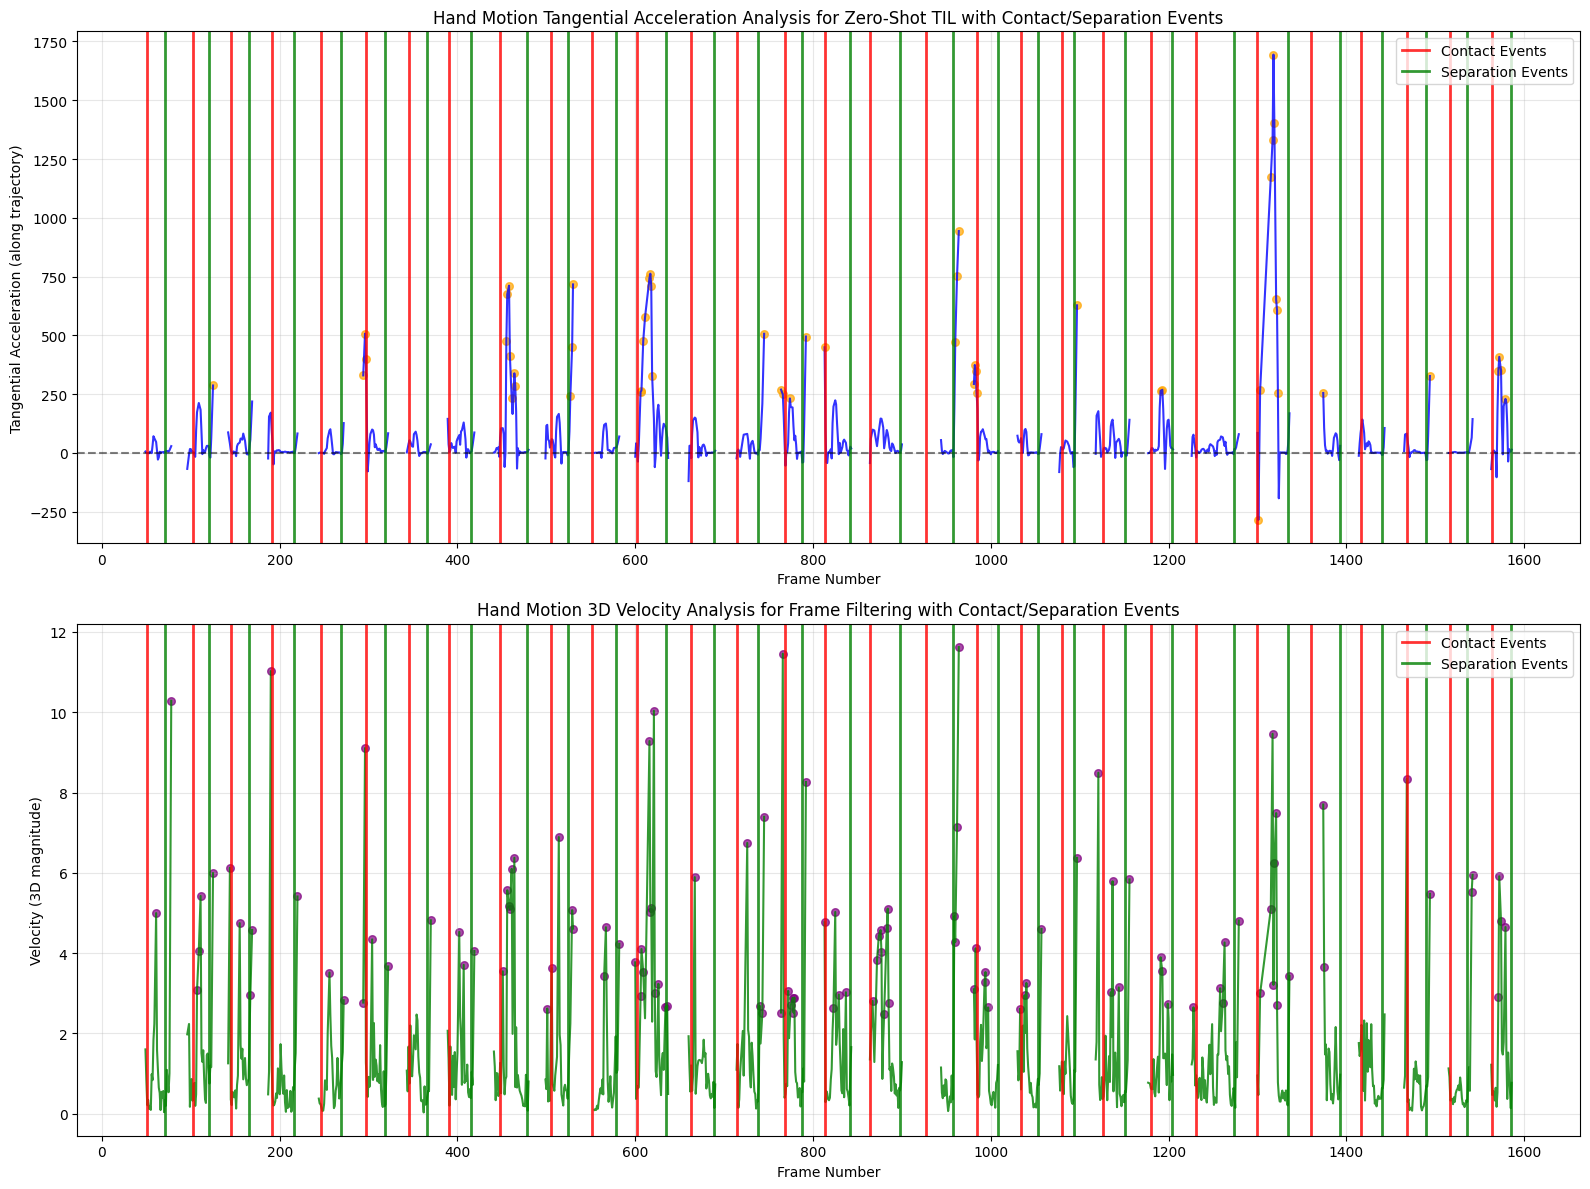


=== Tangential Acceleration-Based Frame Filtering Insights ===
Total frames analyzed: 820
Tangential acceleration range: -285.45 to 1694.17
3D Velocity range: 0.03 to 11.62
High-motion tangential acceleration threshold: 224.79
High-motion velocity threshold: 2.49
High-motion frames for filtering: 131 (16.0%)

=== Contact/Separation Tangential Acceleration Analysis ===
Clip 1: Contact-to-Separation duration = 20 frames
Clip 2: Contact-to-Separation duration = 17 frames
Clip 3: Contact-to-Separation duration = 21 frames
Clip 4: Contact-to-Separation duration = 25 frames
Clip 5: Contact-to-Separation duration = 23 frames
Clip 6: Contact-to-Separation duration = 22 frames
Clip 7: Contact-to-Separation duration = 20 frames
Clip 8: Contact-to-Separation duration = 24 frames
Clip 9: Contact-to-Separation duration = 30 frames
Clip 10: Contact-to-Separation duration = 19 frames
Clip 11: Contact-to-Separation duration = 27 frames
Clip 12: Contact-to-Separation duration = 33 frames
Clip 13: Cont

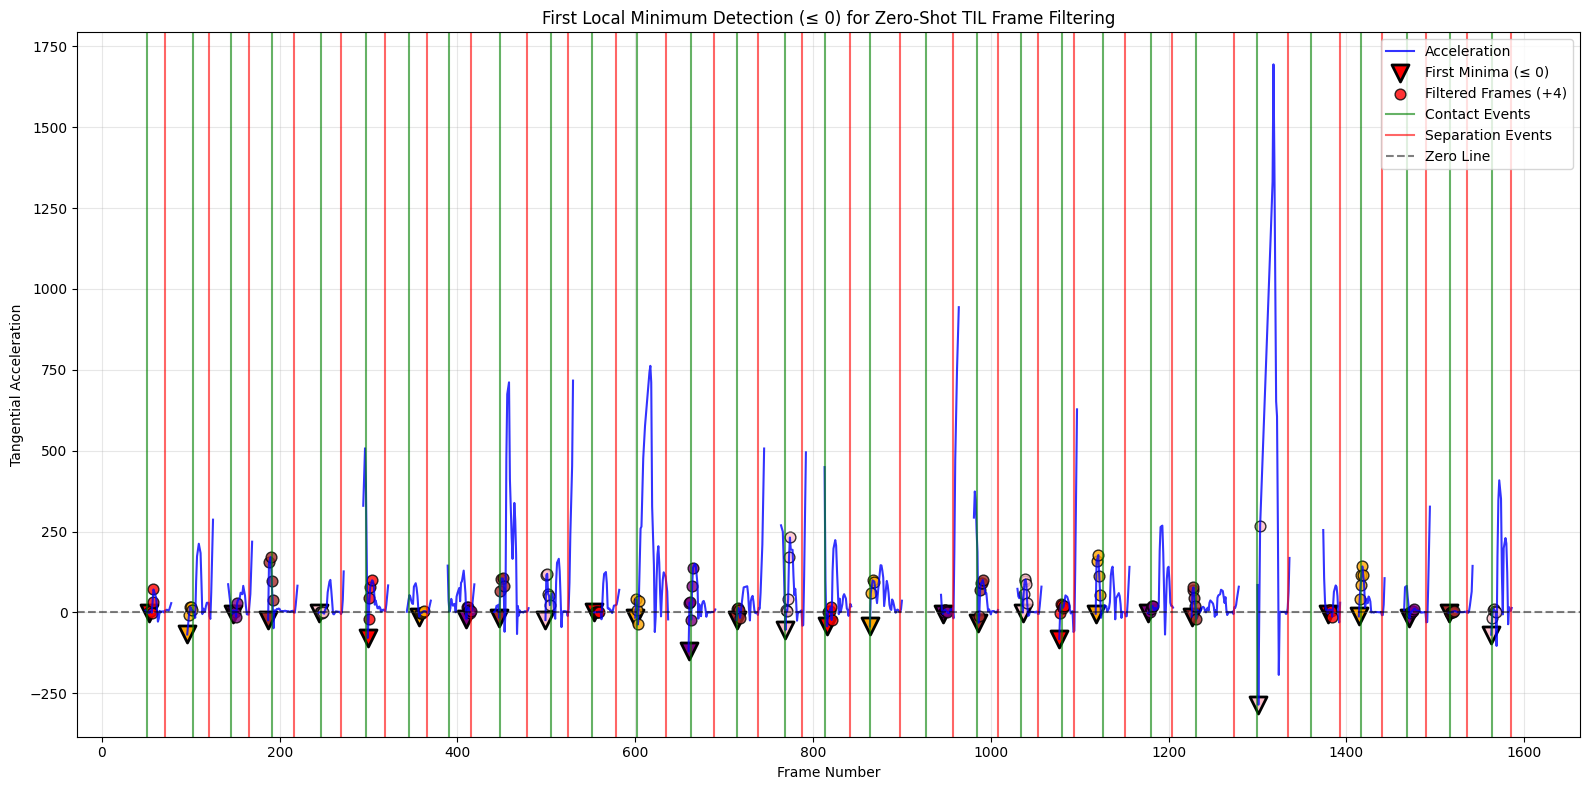

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.signal import savgol_filter



def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data


def parse_clip_ranges(filename):
    """Parse clip ranges file with robust error handling."""
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        # Match pattern "number. start_frame, end_frame"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    
    return clip_ranges


def parse_cs_annot(filename):
    """Parse contact and separation annotations with robust error handling."""
    cs_annotations = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        # Match pattern "index. contact, separation"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            contact = int(match.group(1))
            separation = int(match.group(2))
            cs_annotations.append((contact, separation))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    
    return cs_annotations


def validate_annotations(clip_ranges, cs_annotations):
    """Validate that contact/separation frames are within clip boundaries."""
    print(f"\n=== Annotation Validation ===")
    print(f"Clip ranges: {len(clip_ranges)} entries")
    print(f"CS annotations: {len(cs_annotations)} entries")
    
    if len(clip_ranges) != len(cs_annotations):
        print(f"⚠️  MISMATCH: {len(clip_ranges)} clips vs {len(cs_annotations)} annotations")
        return False
    
    validation_passed = True
    for i, ((start, end), (contact, separation)) in enumerate(zip(clip_ranges, cs_annotations)):
        clip_num = i + 1
        
        # Check if contact is within clip range
        if not (start <= contact <= end):
            print(f"❌ Clip {clip_num}: Contact frame {contact} outside range ({start}-{end})")
            validation_passed = False
        
        # Check if separation is within clip range
        if not (start <= separation <= end):
            print(f"❌ Clip {clip_num}: Separation frame {separation} outside range ({start}-{end})")
            validation_passed = False
        
        # Check if contact comes before separation
        if contact >= separation:
            print(f"❌ Clip {clip_num}: Contact {contact} should be before separation {separation}")
            validation_passed = False
        
        if validation_passed:
            print(f"✅ Clip {clip_num}: Contact {contact}, Separation {separation} (within {start}-{end})")
    
    return validation_passed


import numpy as np
from typing import List, Tuple

def calculate_hand_tangential_acceleration(
    landmarks: List[dict],
    fps: int = 30,
    alpha: float = 1.0,          # 0.5 – 1.0 recommended
) -> Tuple[List[float], List[float]]:
    """
    Tangential acceleration amplified by instantaneous z-speed.

    a_tan_raw  = (a · v̂)                 # classic tangential accel (signed)
    v_z        = z–component of velocity
    a_tan_amp  = |v_z|^alpha · a_tan_raw  # boosts events with high depth speed

    Returns
    -------
    a_tan_amp : list[float]  — length N-2, aligned with frames[2:]
    speed_mag : list[float]  — |v| at frames[2:]  (same alignment)
    """
    if len(landmarks) < 3:
        return [], []

    # 1. positions and dt
    pos = np.array([[lm["x"], lm["y"], lm["z"]] for lm in landmarks])
    dt  = 1.0 / fps

    # 2. velocities (N-1,3) and accelerations (N-2,3)
    vel = np.diff(pos, axis=0) / dt
    acc = np.diff(vel, axis=0) / dt

    # 3. classic tangential acceleration
    a_tan = []
    for i in range(len(acc)):                # i ↔ frame index 2+i
        v  = vel[i + 1]
        a  = acc[i]
        v_norm = np.linalg.norm(v)
        a_tan.append(np.dot(a, v) / v_norm if v_norm > 1e-10 else 0.0)
    a_tan = np.array(a_tan)                  # shape (N-2,)

    # 4. instantaneous z-speed aligned with a_tan  (vel[1:] ↔ frames[2:])
    v_z_aligned = vel[1:, 2]                 # (N-2,)

    # 5. amplitude weighting  |v_z|^alpha · a_tan
    a_tan_amp = (np.abs(v_z_aligned) ** alpha) * a_tan

    # 6. 3-D speed magnitude (aligned with a_tan)
    speed_mag = np.linalg.norm(vel[1:], axis=1)

    return a_tan_amp.tolist(), speed_mag.tolist()


def smooth_acceleration(acc_list, window=5, poly=3):
    """
    Apply Savitzky–Golay filter to tangential-acceleration samples.

    • window: odd integer ≥3.  Choose 5–7 for 30 fps clips.
    • poly  : polynomial order (≤window-1).  order=3 works well for hand motion.
    """
    if len(acc_list) < window:          # too few points → return raw
        return acc_list
    return savgol_filter(acc_list, window, poly).tolist()


def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips with tangential acceleration analysis."""
    clip_data = []
    
    for clip_idx, (start_frame, end_frame) in enumerate(clip_ranges):
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        print(f"Clip {clip_idx + 1} ({start_frame}-{end_frame}): Found {len(clip_landmarks)} landmark frames")
        
        if len(clip_landmarks) >= 3:
            # Use tangential acceleration
            accelerations_raw, velocities = calculate_hand_tangential_acceleration(clip_landmarks, fps)
            accelerations = smooth_acceleration(accelerations_raw, window=7, poly=3)        #w=7, p=3
            # Acceleration starts from frame 2 in the clip
            accel_frames = clip_frames[2:]
            # Velocities are already aligned with acceleration frames
            
            clip_data.append({
                'frames': accel_frames,
                'velocities': velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame),
                'clip_index': clip_idx
            })
        else:
            print(f"⚠️  Clip {clip_idx + 1}: Not enough landmarks for motion analysis")
    
    return clip_data


def create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations):
    """Create disjoint plots with tangential acceleration for zero-shot TIL research."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot TANGENTIAL acceleration with disjoint segments
    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8)
        all_accelerations.extend(clip['accelerations'])
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Tangential Acceleration (along trajectory)')
    ax1.set_title('Hand Motion Tangential Acceleration Analysis for Zero-Shot TIL with Contact/Separation Events')
    ax1.grid(True, alpha=0.3)
    
    # Add ONLY contact and separation lines with legends
    contact_label_added = False
    separation_label_added = False
    
    # Use min length to avoid index errors
    annotation_count = min(len(clip_data), len(cs_annotations))
    print(f"\nAdding annotations for {annotation_count} clips")
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        # Add labels only once for legend
        if not contact_label_added:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high tangential acceleration regions WITHOUT legend
    if all_accelerations:
        high_accel_threshold = np.std(all_accelerations) * 1.5
        for clip in clip_data:
            high_indices = [i for i, acc in enumerate(clip['accelerations']) 
                          if abs(acc) > high_accel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['accelerations'][i] for i in high_indices]
                ax1.scatter(high_frames, high_values, c='orange', s=30, alpha=0.7)
    
    # Show ONLY Contact/Separation legends
    ax1.legend(loc='upper right')
    
    # Plot velocity with disjoint segments
    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['velocities'], 'g-', 
                linewidth=1.5, alpha=0.8)
        all_velocities.extend(clip['velocities'])
    
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (3D magnitude)')
    ax2.set_title('Hand Motion 3D Velocity Analysis for Frame Filtering with Contact/Separation Events')
    ax2.grid(True, alpha=0.3)
    
    # Add ONLY contact and separation lines for velocity plot
    contact_label_added = False
    separation_label_added = False
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        if not contact_label_added:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high velocity regions WITHOUT legend
    if all_velocities:
        high_vel_threshold = np.std(all_velocities) * 1.5
        for clip in clip_data:
            high_indices = [i for i, vel in enumerate(clip['velocities']) 
                          if vel > high_vel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['velocities'][i] for i in high_indices]
                ax2.scatter(high_frames, high_values, c='purple', s=30, alpha=0.7)
    
    # Show ONLY Contact/Separation legends
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig


def main():
    """Main function with tangential acceleration analysis for zero-shot TIL research."""
    landmarks_file = "../test_data/5th_landmarks_bC1_30.txt"
    clip_ranges_file = "../test_data/clip_ranges_30.txt"
    cs_annot_file = "../test_data/cs_annot_30.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Loading contact/separation annotations...")
    cs_annotations = parse_cs_annot(cs_annot_file)
    print(f"Loaded {len(cs_annotations)} contact/separation pairs")
    
    # Validate annotations
    validation_passed = validate_annotations(clip_ranges, cs_annotations)
    if not validation_passed:
        print("⚠️  Validation failed, but continuing with analysis...")
    
    print("\nProcessing landmarks by clips with tangential acceleration...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    
    print(f"\n=== Tangential Acceleration Motion Analysis Results ===")
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames with motion data")
    
    # Create enhanced plots with tangential acceleration annotations
    print("\n=== Creating Tangential Acceleration Plots for Zero-Shot TIL Research ===")
    fig = create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations)
    
    # Generate insights for tangential acceleration-based frame filtering
    print("\n=== Tangential Acceleration-Based Frame Filtering Insights ===")
    
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_accelerations = [acc for clip in clip_data for acc in clip['accelerations']]
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    
    if all_accelerations and all_velocities:
        accel_threshold = np.std(all_accelerations) * 1.5
        vel_threshold = np.std(all_velocities) * 1.5
        
        # Count high-motion frames for filtering insights
        high_motion_count = 0
        for clip in clip_data:
            for acc, vel in zip(clip['accelerations'], clip['velocities']):
                if abs(acc) > accel_threshold or vel > vel_threshold:
                    high_motion_count += 1
        
        print(f"Total frames analyzed: {total_frames}")
        print(f"Tangential acceleration range: {min(all_accelerations):.2f} to {max(all_accelerations):.2f}")
        print(f"3D Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
        print(f"High-motion tangential acceleration threshold: {accel_threshold:.2f}")
        print(f"High-motion velocity threshold: {vel_threshold:.2f}")
        print(f"High-motion frames for filtering: {high_motion_count} ({high_motion_count/total_frames*100:.1f}%)")
        
        # Analyze motion patterns around contact/separation events
        print(f"\n=== Contact/Separation Tangential Acceleration Analysis ===")
        for i, (contact, separation) in enumerate(cs_annotations):
            duration = separation - contact
            print(f"Clip {i+1}: Contact-to-Separation duration = {duration} frames")
    
    # ACCELERATION-BASED FRAME FILTERING for Zero-Shot TIL
    print("\n=== First Local Minimum (≤ 0) Frame Filtering for Zero-Shot TIL ===")
    
    filtered_sequences = detect_first_acceleration_minimum_frames(
        clip_data, 
        prominence_threshold=0.1,
        distance_threshold=3,
        frames_after_minimum=5
    )
    
    # Extract all filtered frames for downstream processing
    all_filtered_frames = extract_all_first_minimum_frames(filtered_sequences)
    
    print(f"\n=== First Minimum Frame Filtering Results ===")
    print(f"Total clips processed: {len(clip_data)}")
    print(f"Clips with valid first minimum: {len([s for s in filtered_sequences.values() if s])}")
    print(f"Total filtered frames: {len(all_filtered_frames)}")
    print(f"Filtered frames: {all_filtered_frames}")
    
    # Show per-clip results
    for clip_idx, sequence in filtered_sequences.items():
        if sequence:
            print(f"Clip {clip_idx + 1}: Frames {sequence}")
        else:
            print(f"Clip {clip_idx + 1}: No valid minimum found")
    
    # Visualize results
    visualize_first_minimum_frames(clip_data, filtered_sequences, cs_annotations)
    return {
        'clip_data': clip_data,
        'filtered_sequences': filtered_sequences,
        'all_filtered_frames': all_filtered_frames,
        'cs_annotations': cs_annotations,
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges,
        'validation_passed': validation_passed
    }

    


if __name__ == "__main__":
    results = main()
    filtered_sequences = results['filtered_sequences']



In [24]:
filtered_sequences

{0: [53, 54, 55, 56, 57, 58],
 1: [96, 97, 98, 99, 100, 101],
 2: [147, 148, 149, 150, 151, 152],
 3: [187, 188, 189, 190, 191, 192],
 4: [244, 245, 246, 247, 248, 249],
 5: [299, 300, 301, 302, 303, 304],
 6: [357, 358, 359, 360, 361, 362],
 7: [410, 411, 412, 413, 414, 415],
 8: [447, 448, 449, 450, 451, 452],
 9: [499, 500, 501, 502, 503, 504],
 10: [554, 555, 556, 557, 558, 559],
 11: [600, 601, 602, 603, 604, 605],
 12: [660, 661, 662, 663, 664, 665],
 13: [714, 715, 716, 717, 718, 719],
 14: [769, 770, 771, 772, 773, 774],
 15: [816, 817, 818, 819, 820, 821],
 16: [864, 865, 866, 867, 868, 869],
 17: [946, 947, 948, 949, 950, 951],
 18: [986, 987, 988, 989, 990, 991],
 19: [1036, 1037, 1038, 1039, 1040, 1041],
 20: [1077, 1078, 1079, 1080, 1081, 1082],
 21: [1118, 1119, 1120, 1121, 1122, 1123],
 22: [1177, 1178, 1179, 1180, 1181, 1182],
 23: [1226, 1227, 1228, 1229, 1230, 1231],
 24: [1301, 1302, 1303, 1304, 1305, 1306],
 25: [1379, 1380, 1381, 1382, 1383, 1384],
 26: [1414, 1415